1. Import

In [12]:
import pandas as pd
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report)
from src.data.preprocessing import (clean_products, split_data, create_preprocessor)
from src.ml.classification import (create_classification_pipeline, create_random_forest_pipeline)


2. Load Data

In [13]:
df = pd.read_csv("../data/raw/products.csv",sep="\t")
print("Dataset Loaded")
print("Shape:", df.shape)
print("Columns:", df.columns)
print("\nFirst 5 rows:", df.head(5))
print("\nData Types:", df.dtypes)

Dataset Loaded
Shape: (200, 7)
Columns: Index(['product_id', 'name', 'category', 'brand', 'price', 'stock', 'rating'], dtype='object')

First 5 rows:    product_id                name category     brand     price  stock  rating
0           1   MacBook Pro M4 14   Laptop     Apple  10677.59   10.0     4.7
1           2    RTX 5070 Ti 16GB      GPU    NVIDIA    771.27   13.0     4.9
2           3   Core Ultra 5 245K      CPU     Intel    323.46   12.0     4.3
3           4      16GB DDR5-5600      RAM  Kingston     50.02   47.0     4.2
4           5  27in 4K OLED 240Hz  Monitor      ASUS     891.3    5.0     4.7

Data Types: product_id      int64
name           object
category       object
brand          object
price          object
stock         float64
rating        float64
dtype: object


3. Basic EDA

In [14]:
print("Shape:", df.shape)
print("\nNull Values:")
print(df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())
print("\nPrice Statistics:")
print(df["price"].describe())
print("\nCategory Distribution:")
print(df["category"].value_counts())

Shape: (200, 7)

Null Values:
product_id    0
name          0
category      0
brand         3
price         2
stock         3
rating        2
dtype: int64

Duplicates: 4

Price Statistics:
count        198
unique       191
top       166.92
freq           2
Name: price, dtype: object

Category Distribution:
category
SSD            36
CPU            30
GPU            27
RAM            24
Case           16
Mouse          15
Monitor        14
Motherboard    12
PSU            11
Headset         8
Laptop          7
Name: count, dtype: int64


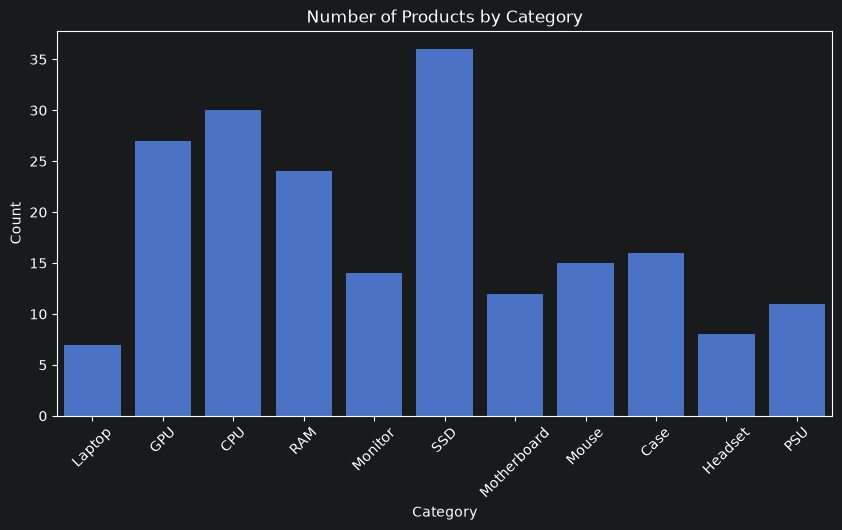

In [15]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x="category")
plt.title("Number of Products by Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

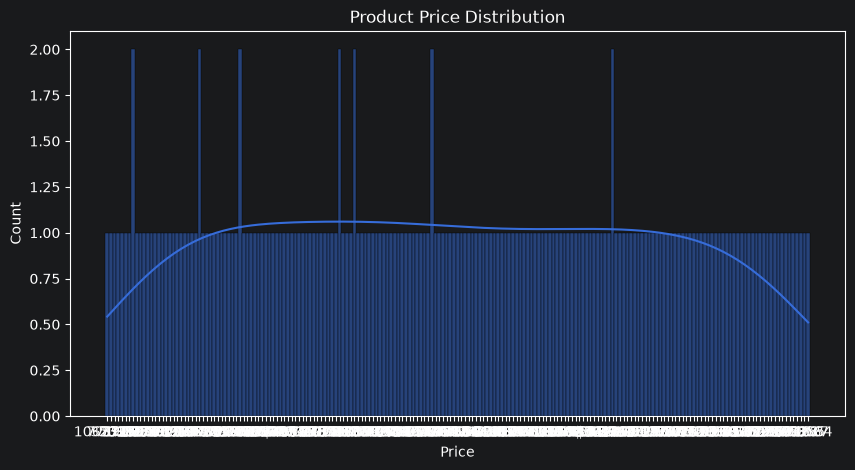

In [16]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="price", bins=20, kde=True)
plt.title("Product Price Distribution")
plt.xlabel("Price")
plt.show()

In [17]:
# category_price = df.groupby("category")["price"].mean()
# print(category_price)
print(df["price"].dtype)
print(df["price"].head(20))
df["price"] = (df["price"].astype(str).str.replace("$","", regex=False))
df["price"] = pd.to_numeric(df["price"], errors="coerce")
print(df["price"].dtype)
category_price = df.groupby("category")["price"].mean()
print(category_price)

object
0     10677.59
1       771.27
2       323.46
3        50.02
4        891.3
5       371.17
6       162.96
7       315.38
8        93.31
9       180.39
10      201.85
11       51.63
12     1971.22
13         NaN
14      354.57
15      597.27
16      154.61
17      386.98
18      161.14
19       77.23
Name: price, dtype: object
float64
category
CPU             369.207000
Case            114.590625
GPU            1115.991538
Headset         278.851250
Laptop         2958.718571
Monitor         675.204286
Motherboard     272.520000
Mouse           156.460667
PSU             147.951818
RAM             116.568750
SSD             130.829167
Name: price, dtype: float64


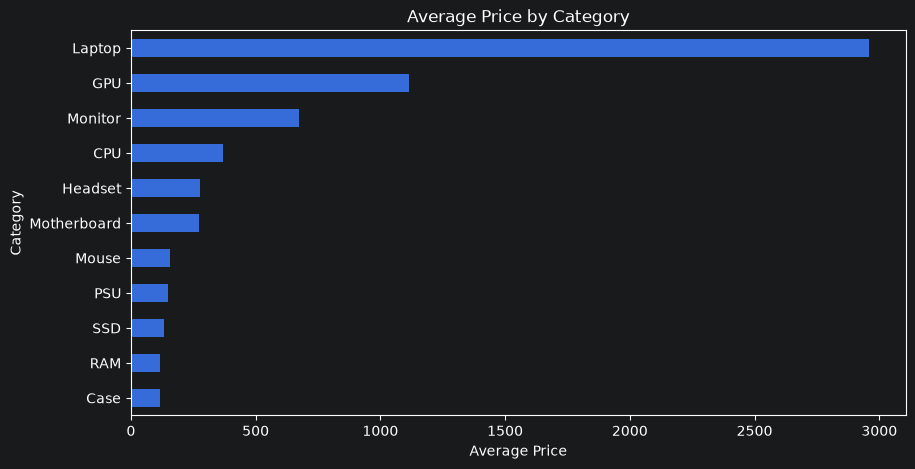

In [18]:
plt.figure(figsize=(10, 5))
category_price.sort_values().plot(kind="barh")
plt.title("Average Price by Category")
plt.xlabel("Average Price")
plt.ylabel("Category")
plt.show()

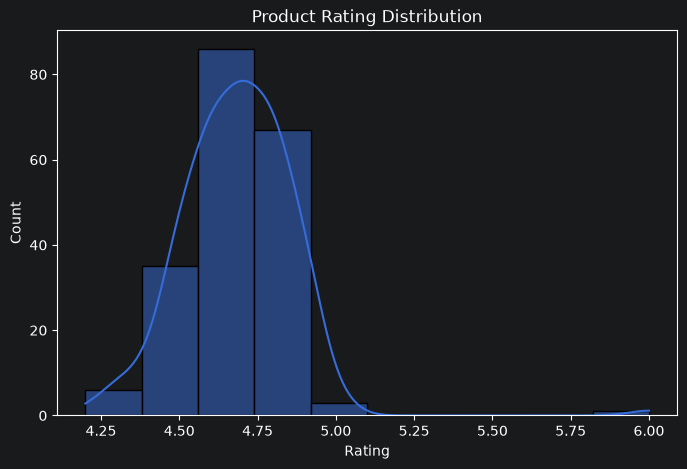

In [19]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="rating", bins=10, kde=True)
plt.title("Product Rating Distribution")
plt.xlabel("Rating")
plt.show()

4. Data Cleaning

In [20]:
df_clean = clean_products(df)
print("Original:", df.shape)
print("Cleaned:", df_clean.shape)
print("Shape:", df_clean.shape)
print("\nData Types:")
print(df_clean.dtypes)
print("\nNull Values:")
print(df_clean.isnull().sum())
print("\nDuplicates:")
print(df_clean.duplicated().sum())
print("\nInvalid prices:", (df_clean["price"] <= 0).sum())
print("Invalid stock:", (df_clean["stock"] < 0).sum())
invalid_rating = ((df_clean["rating"] < 0) | (df_clean["rating"] > 5)).sum()
print("Invalid Rating:", invalid_rating)

Original: (200, 7)
Cleaned: (188, 7)
Shape: (188, 7)

Data Types:
product_id      int64
name           object
category       object
brand          object
price         float64
stock         float64
rating        float64
dtype: object

Null Values:
product_id    0
name          0
category      0
brand         3
price         0
stock         0
rating        0
dtype: int64

Duplicates:
0

Invalid prices: 0
Invalid stock: 0
Invalid Rating: 0


In [21]:
df_clean.to_csv("../data/processed/cleaned.csv", index=False)
print("Cleaned dataset saved.")

Cleaned dataset saved.


5. Train/ Validation/ Test

In [22]:
train_df, val_df, test_df = split_data(df_clean)

print("Original:", df.shape)
print("Cleaned:", df_clean.shape)
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)
train_df.to_csv("../data/splits/train.csv", index=False)
val_df.to_csv("../data/splits/validation.csv", index=False)
test_df.to_csv("../data/splits/test.csv", index=False)
print("Train / Validation / Test files saved successfully.")

Original: (200, 7)
Cleaned: (188, 7)
Train: (150, 7)
Validation: (19, 7)
Test: (19, 7)
Train / Validation / Test files saved successfully.


6. Reload Save Splits

In [23]:
train_df = pd.read_csv("../data/splits/train.csv")
val_df = pd.read_csv("../data/splits/validation.csv")
test_df = pd.read_csv("../data/splits/test.csv")
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (150, 7)
Validation: (19, 7)
Test: (19, 7)


7. Feature / Target Preparation

In [24]:
x_train = train_df.drop(columns=["category", "product_id", "name"])
x_val = val_df.drop(columns=["category", "product_id", "name"])
x_test = test_df.drop(columns=["category", "product_id", "name"])
y_train = train_df["category"]
y_val = val_df["category"]
y_test = test_df["category"]
print("x_train:", x_train.shape)
print("x_val:", x_val.shape)
print("x_test:", x_test.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)
print("\nTarget Distribution:")
print(y_train.value_counts())

x_train: (150, 4)
x_val: (19, 4)
x_test: (19, 4)
y_train: (150,)
y_val: (19,)
y_test: (19,)

Target Distribution:
category
SSD            29
CPU            22
GPU            21
RAM            19
Mouse          14
Monitor        13
Case           10
PSU             9
Motherboard     6
Laptop          5
Headset         2
Name: count, dtype: int64


8. Preprocessing Inspection

In [25]:
preprocessor = create_preprocessor()
# Fit ONLY on training data.
preprocessor.fit(x_train)
x_train_processed = preprocessor.transform(x_train)
x_val_processed = preprocessor.transform(x_val)
x_test_processed = preprocessor.transform(x_test)
print("Original x_train:", x_train.shape)
print("Processed x_train:", x_train_processed.shape)
print("\nOriginal x_val:", x_val.shape)
print("Processed x_val:", x_val_processed.shape)
print("\nOriginal x_test:", x_test.shape)
print("Processed x_test:", x_test_processed.shape)


Original x_train: (150, 4)
Processed x_train: (150, 27)

Original x_val: (19, 4)
Processed x_val: (19, 27)

Original x_test: (19, 4)
Processed x_test: (19, 27)


9. Logistic Regression

In [26]:
logistic_pipeline = create_classification_pipeline()
logistic_pipeline.fit(x_train, y_train)
y_val_pred_logistic = logistic_pipeline.predict(x_val)
y_test_pred_logistic = logistic_pipeline.predict(x_test)
print(logistic_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['brand']),
                                                 ('numerical', StandardScaler(),
                                                  ['price', 'stock',
                                                   'rating'])])),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])


In [27]:
logistic_val_accuracy = accuracy_score(y_val, y_val_pred_logistic)
logistic_test_accuracy = accuracy_score(y_test, y_test_pred_logistic)
print("Logistic Regression Validation Accuracy:", logistic_val_accuracy)
print("Logistic Regression Test Accuracy:", logistic_test_accuracy)

Logistic Regression Validation Accuracy: 0.6842105263157895
Logistic Regression Test Accuracy: 0.7368421052631579


In [28]:
print("Actual:")
print(y_val.iloc[:10].values)
print("\nPredicted:")
print(y_val_pred_logistic[:10])
print("\nClasses:")
print(logistic_pipeline.named_steps["model"].classes_)

Actual:
['Motherboard' 'Motherboard' 'SSD' 'CPU' 'RAM' 'SSD' 'SSD' 'Case' 'Mouse'
 'Headset']

Predicted:
['Mouse' 'SSD' 'SSD' 'CPU' 'RAM' 'SSD' 'SSD' 'Case' 'Mouse' 'SSD']

Classes:
['CPU' 'Case' 'GPU' 'Headset' 'Laptop' 'Monitor' 'Motherboard' 'Mouse'
 'PSU' 'RAM' 'SSD']


In [29]:
y_val_proba_logistic = (logistic_pipeline.predict_proba(x_val))
print("Probability shape:")
print(y_val_proba_logistic.shape)
print("\nFirst sample probabilities:")
print(y_val_proba_logistic[0])

Probability shape:
(19, 11)

First sample probabilities:
[0.12353523 0.09685092 0.07765069 0.04551272 0.02431973 0.10155682
 0.06276911 0.16915037 0.11929208 0.01800652 0.16135578]


In [30]:
print("Logistic Regression Classification Report:")
print(classification_report(y_val, y_val_pred_logistic, zero_division=0))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

         CPU       1.00      1.00      1.00         2
        Case       1.00      1.00      1.00         2
         GPU       1.00      1.00      1.00         1
     Headset       0.00      0.00      0.00         3
     Monitor       0.33      1.00      0.50         1
 Motherboard       1.00      0.25      0.40         4
       Mouse       0.50      1.00      0.67         1
         RAM       1.00      1.00      1.00         2
         SSD       0.50      1.00      0.67         3

    accuracy                           0.68        19
   macro avg       0.70      0.81      0.69        19
weighted avg       0.70      0.68      0.62        19



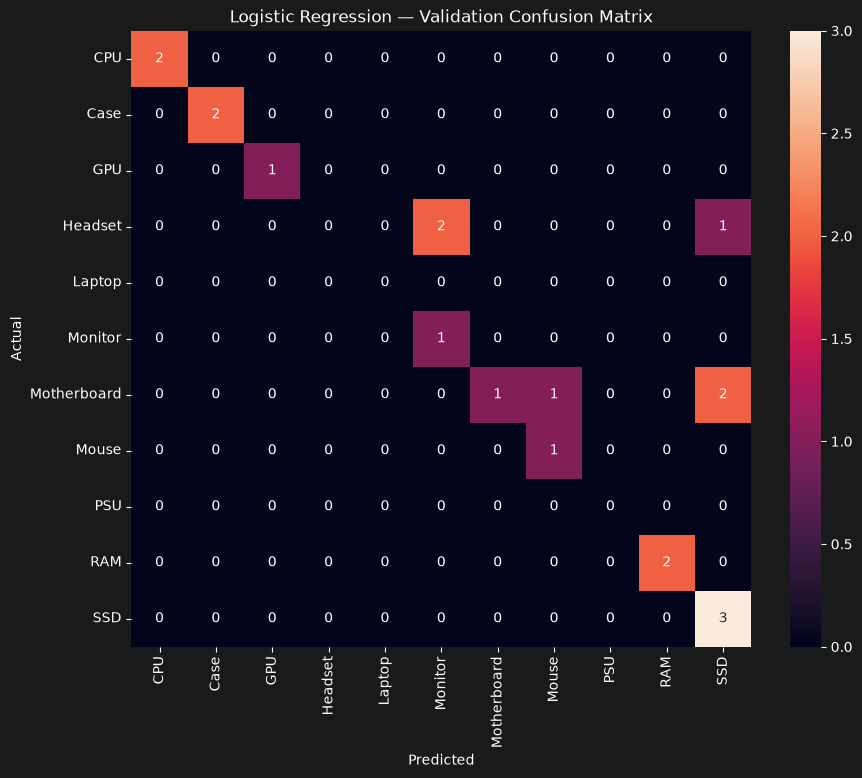

In [31]:
logistic_classes = (logistic_pipeline.named_steps["model"].classes_)
cm_logistic = confusion_matrix(y_val, y_val_pred_logistic, labels=logistic_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_logistic, annot=True, fmt="d", xticklabels=logistic_classes, yticklabels=logistic_classes)
plt.title("Logistic Regression — Validation Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [32]:
print("Logistic Regression Test Classification Report:")
print(classification_report(y_test, y_test_pred_logistic, zero_division=0))

Logistic Regression Test Classification Report:
              precision    recall  f1-score   support

         CPU       1.00      1.00      1.00         4
        Case       1.00      0.75      0.86         4
         GPU       1.00      1.00      1.00         2
     Headset       0.00      0.00      0.00         1
      Laptop       0.00      0.00      0.00         1
     Monitor       0.00      0.00      0.00         0
 Motherboard       0.00      0.00      0.00         1
         PSU       1.00      1.00      1.00         2
         RAM       0.00      0.00      0.00         1
         SSD       0.60      1.00      0.75         3

    accuracy                           0.74        19
   macro avg       0.46      0.47      0.46        19
weighted avg       0.73      0.74      0.72        19



10. Random Forest

In [33]:
rf_pipeline = create_random_forest_pipeline()
rf_pipeline.fit(x_train, y_train)
y_val_pred_rf = rf_pipeline.predict(x_val)
y_test_pred_rf = rf_pipeline.predict(x_test)

In [34]:
rf_val_accuracy = accuracy_score(y_val, y_val_pred_rf)
rf_test_accuracy = accuracy_score(y_test, y_test_pred_rf)
print("Random Forest Validation Accuracy:", rf_val_accuracy)
print("Random Forest Test Accuracy:", rf_test_accuracy)

Random Forest Validation Accuracy: 0.8947368421052632
Random Forest Test Accuracy: 0.8421052631578947


In [35]:
print("Random Forest Validation Classification Report:")
print(classification_report(y_val, y_val_pred_rf, zero_division=0))

Random Forest Validation Classification Report:
              precision    recall  f1-score   support

         CPU       0.50      1.00      0.67         2
        Case       1.00      1.00      1.00         2
         GPU       1.00      1.00      1.00         1
     Headset       1.00      0.33      0.50         3
     Monitor       1.00      1.00      1.00         1
 Motherboard       1.00      1.00      1.00         4
       Mouse       1.00      1.00      1.00         1
         RAM       1.00      1.00      1.00         2
         SSD       1.00      1.00      1.00         3

    accuracy                           0.89        19
   macro avg       0.94      0.93      0.91        19
weighted avg       0.95      0.89      0.89        19



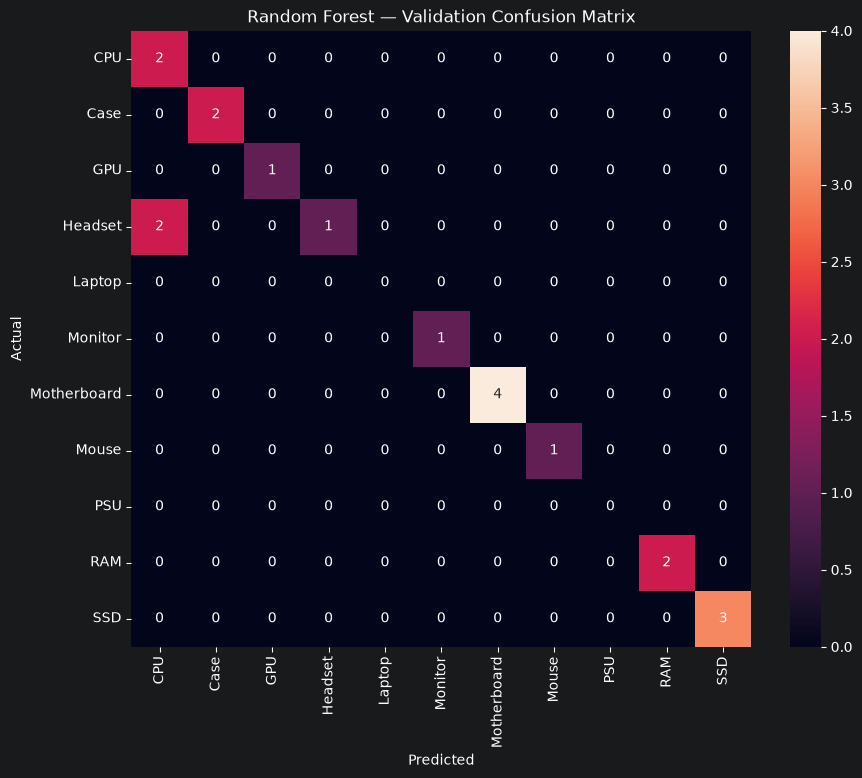

In [36]:
rf_classes = (rf_pipeline.named_steps["model"].classes_)
cm_rf = confusion_matrix(y_val, y_val_pred_rf, labels=rf_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_rf, annot=True, fmt="d", xticklabels=rf_classes, yticklabels=rf_classes)
plt.title("Random Forest — Validation Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [37]:
print("Random Forest Test Classification Report:")
print(classification_report(y_test, y_test_pred_rf, zero_division=0))

Random Forest Test Classification Report:
              precision    recall  f1-score   support

         CPU       0.80      1.00      0.89         4
        Case       1.00      0.75      0.86         4
         GPU       1.00      1.00      1.00         2
     Headset       0.00      0.00      0.00         1
      Laptop       1.00      1.00      1.00         1
 Motherboard       1.00      1.00      1.00         1
         PSU       1.00      1.00      1.00         2
         RAM       0.00      0.00      0.00         1
         SSD       0.60      1.00      0.75         3

    accuracy                           0.84        19
   macro avg       0.71      0.75      0.72        19
weighted avg       0.79      0.84      0.80        19



11. Model Comparison

In [38]:
print("=== MODEL COMPARISON ===")
print("Logistic Regression Validation Accuracy:", logistic_val_accuracy)
print("Logistic Regression Test Accuracy:", logistic_test_accuracy)
print("Random Forest Validation Accuracy:", rf_val_accuracy)
print("Random Forest Test Accuracy:", rf_test_accuracy)

=== MODEL COMPARISON ===
Logistic Regression Validation Accuracy: 0.6842105263157895
Logistic Regression Test Accuracy: 0.7368421052631579
Random Forest Validation Accuracy: 0.8947368421052632
Random Forest Test Accuracy: 0.8421052631578947


12. Save Both Model

In [39]:
logistic_model_path = ("../models/logistic_regression_classifier.joblib")
rf_model_path = ("../models/random_forest_classifier.joblib")
joblib.dump(logistic_pipeline, logistic_model_path)
joblib.dump(rf_pipeline, rf_model_path)
print("Both models saved successfully.")

Both models saved successfully.


In [40]:
print("Logistic Regression exists:", os.path.exists(logistic_model_path))
print("Random Forest exists:",os.path.exists(rf_model_path))

Logistic Regression exists: True
Random Forest exists: True


13. Reload Both Models

In [41]:
loaded_logistic = joblib.load(logistic_model_path)
loaded_rf = joblib.load(rf_model_path)
print("Both models loaded successfully.")

Both models loaded successfully.


14. Verify Reloaded Models

In [42]:
logistic_loaded_pred = (loaded_logistic.predict(x_test))
rf_loaded_pred = (loaded_rf.predict(x_test))
logistic_reload_ok = (logistic_loaded_pred == y_test_pred_logistic).all()
rf_reload_ok = (rf_loaded_pred == y_test_pred_rf).all()
print("Logistic Regression reload test:", logistic_reload_ok)
print("Random Forest reload test:", rf_reload_ok)

Logistic Regression reload test: True
Random Forest reload test: True


In [43]:
loaded_logistic_test_accuracy = accuracy_score(y_test, logistic_loaded_pred)
loaded_rf_test_accuracy = accuracy_score(y_test, rf_loaded_pred)
print("Loaded Logistic Regression Test Accuracy:", loaded_logistic_test_accuracy)
print("Loaded Random Forest Test Accuracy:", loaded_rf_test_accuracy)

Loaded Logistic Regression Test Accuracy: 0.7368421052631579
Loaded Random Forest Test Accuracy: 0.8421052631578947
